In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Numerical Analysis

In [2]:
df = pd.read_csv('token_usage_log.csv')
print("Data Info:")
display(df.info())
print("\nData Description:")
display(df.describe())
print("\nFirst Few Rows:")
display(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               140 non-null    object 
 1   Step                    140 non-null    object 
 2   Input Tokens (Prompt)   140 non-null    int64  
 3   Output Tokens (Answer)  140 non-null    int64  
 4   Total Tokens            140 non-null    int64  
 5   Latency (s)             75 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.7+ KB


None


Data Description:


,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
count,140.000000,140.000000,140.000000,75.000000
mean,9626.800000,211.542857,10992.107143,5.118133
std,11468.598144,268.229081,13466.346555,4.883361
min,304.000000,3.000000,366.000000,0.910000
25%,732.750000,40.750000,864.000000,1.955000
50%,989.500000,114.000000,1678.500000,4.180000
75%,22882.000000,289.500000,23527.750000,5.875000
max,27433.000000,1526.000000,46895.000000,26.620000



First Few Rows:


,Timestamp,Step,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
0,2026-04-19 16:44:36,Router_RB,668,14,682,NaN
1,2026-04-19 16:44:39,Generator_RB,486,205,691,NaN
2,2026-04-19 16:46:11,Router_RB,661,25,686,NaN
3,2026-04-19 16:46:14,Generator_RB,1240,100,1340,NaN
4,2026-04-19 17:03:17,Generator_RB,455,268,723,NaN


In [16]:
df = df.rename(columns={
    'Input Tokens (Prompt)': 'Input Tokens',
    'Output Tokens (Answer)': 'Output Tokens',
    'Latency (s)': 'Latency'
})

df['Extra Tokens'] = df['Total Tokens'] - df['Input Tokens'] - df['Output Tokens']
df['Model'] = df['Step'].apply(lambda x: 'Naive' if '_Naive' in x else 'Router Based')

df.head()

,Timestamp,Step,Input Tokens,Output Tokens,Total Tokens,Latency,Extra Tokens,Model
0,2026-04-19 16:44:36,Router_RB,668,14,682,NaN,0,Router Based
1,2026-04-19 16:44:39,Generator_RB,486,205,691,NaN,0,Router Based
2,2026-04-19 16:46:11,Router_RB,661,25,686,NaN,0,Router Based
3,2026-04-19 16:46:14,Generator_RB,1240,100,1340,NaN,0,Router Based
4,2026-04-19 17:03:17,Generator_RB,455,268,723,NaN,0,Router Based


In [19]:
step_token_usage_df = df.groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].mean().reset_index() 
display(step_token_usage_df)
step_time_usage_df = df.groupby(['Step', 'Model'])['Latency'].mean().reset_index()
display(step_time_usage_df)

model_token_usage_df = step_token_usage_df.groupby('Model')[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].sum().reset_index()
display(model_token_usage_df)
model_time_usage_df = step_time_usage_df.groupby('Model')['Latency'].sum().reset_index()
display(model_time_usage_df)

,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,Evaluator_Naive,Naive,26923.727273,59.181818,0.000000,26982.909091
1,Evaluator_RB,Router Based,1218.733333,94.666667,0.000000,1313.400000
2,Generator_Naive,Naive,24357.500000,369.552632,3858.605263,28585.657895
3,Generator_RB,Router Based,668.536585,322.073171,319.121951,1309.731707
4,Router_RB,Router Based,2294.714286,8.485714,51.885714,2355.085714


,Step,Model,Latency
0,Evaluator_Naive,Naive,7.549091
1,Evaluator_RB,Router Based,2.872000
2,Generator_Naive,Naive,7.231875
3,Generator_RB,Router Based,5.930000
4,Router_RB,Router Based,2.773529


,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,Naive,51281.227273,428.734450,3858.605263,55568.566986
1,Router Based,4181.984204,425.225552,371.007666,4978.217422


,Model,Latency
0,Naive,14.780966
1,Router Based,11.575529


## Plots

### Cmap

In [5]:
# Colormap for each Step category
router_based = "#3cb6aed6"
full_db = "#f93e3e"

step_cmap = {
    'Router_RB': router_based,
    'Generator_RB': router_based,
    'Generator_Naive': full_db,
    'Evaluator_RB': router_based,
    'Evaluator_Naive': full_db
}

model_cmap = {
    'Router Based': router_based,
    'Naive': full_db
}

### Comparison

#### Average token per model

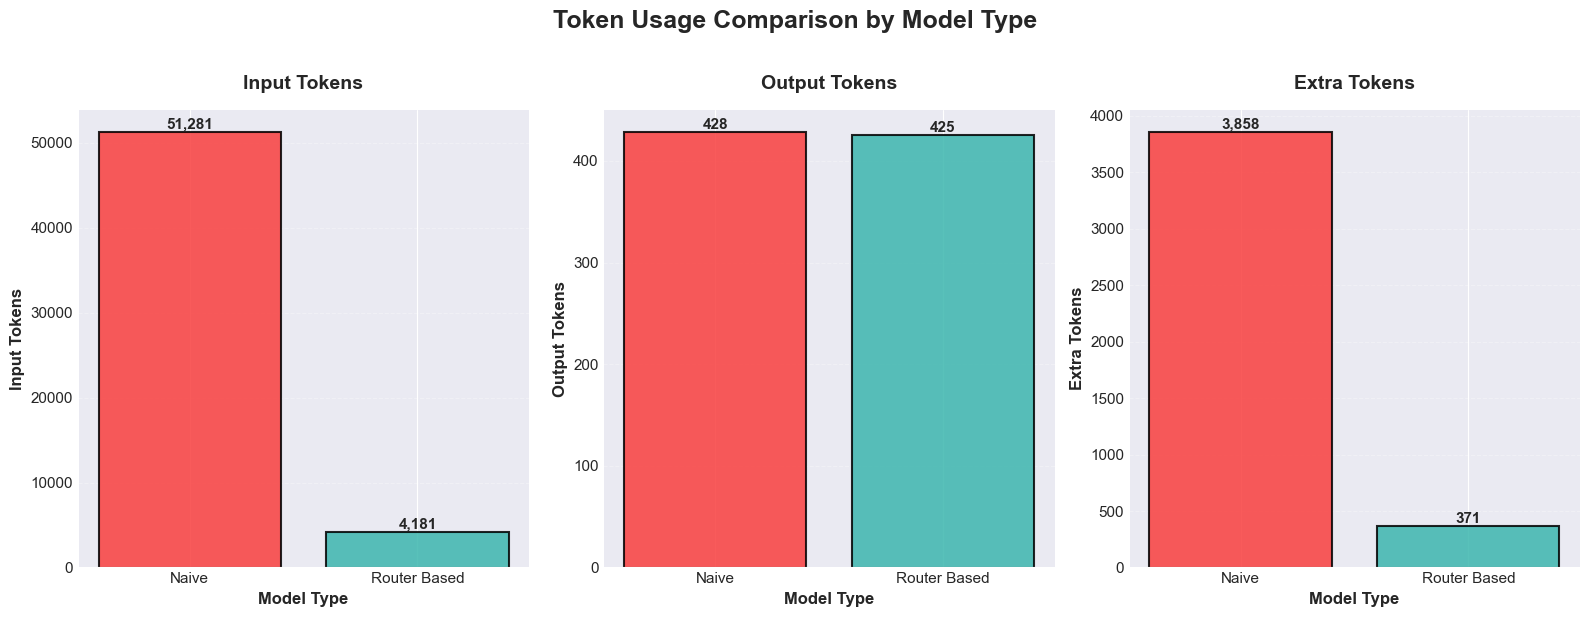

In [34]:
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Token Usage Comparison by Model Type', fontsize=18, fontweight='bold', y=1.02)

metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    
    bars = ax.bar(model_token_usage_df['Model'], model_token_usage_df[metric], 
                   color=[model_cmap[model] for model in model_token_usage_df['Model']],
                   edgecolor='black', linewidth=1.5, alpha=0.85)
    
    ax.set_title(f'{metric}', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Improve tick labels
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.show()

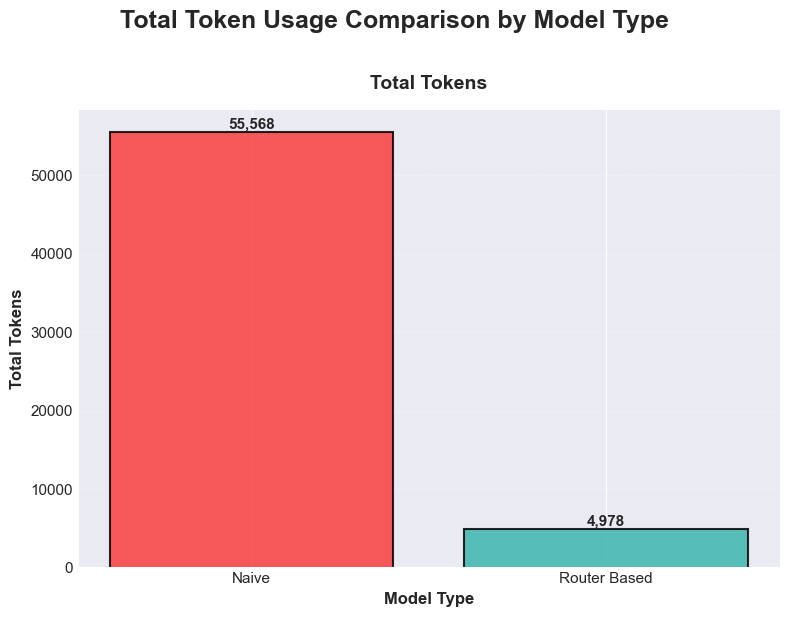

In [35]:
plt.style.use('seaborn-v0_8-darkgrid')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle('Total Token Usage Comparison by Model Type', fontsize=18, fontweight='bold', y=1.02)

bars = ax.bar(
    model_token_usage_df['Model'],
    model_token_usage_df['Total Tokens'],
    color=[model_cmap[model] for model in model_token_usage_df['Model']],
    edgecolor='black',
    linewidth=1.5,
    alpha=0.85
)

ax.set_title('Total Tokens', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Tokens', fontsize=12, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=11)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle('Total Latency Comparison by Model Type', fontsize=18, fontweight='bold', y=1.02)

bars = ax.bar(
    model_time_usage_df['Model'],
    model_time_usage_df['Latency'],
    color=[model_cmap[model] for model in model_time_usage_df['Model']],
    edgecolor='black',
    linewidth=1.5,
    alpha=0.85
)

ax.set_title('Total Latency', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Latency (s)', fontsize=12, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=11)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.show()